# Image classification using SVM

In this demonstration code, we'll learn how to use SVM to classify images.

This dataset is  obtained from [https://mds-book.org/Content/datasets](https://mds-book.org/Content/datasets), which is the supplementary data of the textbook *Materials Data Science: Introduction to Data Mining, Machine Learning, and Data-Driven Predictions for Materials Science and Engineering* (2024) by Stefan Sandfeld. The author has made a `mdsdata` Python library and a `load_Ising()` method.

This dataset contains 5000 results of Ising model simulations, spreading across a wide range of temperature.

## Part 1 Load images

Use the cell below to import data. `images` contains 5000 sets of 64x64 pixel images. `labels` contains 0 and 1, which indicate below and above Curie temperature, respectively. `temperatures` contains the corresponding values of temperature. We will plot two of the images too: one below and the other above $T_C$. **DO you still remember what is the Curie temperature is?** For a simple Ising model Monte Carlo simulation, what is the value?

In [ ]:
import numpy as np
from mdsdata import load_Ising

images, labels, temperatures = load_Ising()

In [ ]:
import matplotlib.pyplot as plt

fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(8, 4))
ax0.imshow(images[10])
ax0.set(title=f"T={temperatures[10]:.2f}, label={labels[10]}")
ax1.imshow(images[3000])
ax1.set(title=f"T={temperatures[3000]:.2f}, label={labels[3000]}")
plt.show()

Each image consists of 64x64 pixels and each pixel has an intensity value. Here it 0 or 255.

In [ ]:
print(images[10])

You should realize the an image is essentially a 2D array, in which each entry indicates the value of pixel intensity. The total of 5000 sets may be too large for this task. So, we extract only 1000 sets randomly from the original dataset. Additionally, the 64x64 pixel images may be too large for further computations. Thus, we will just grab a 32x32 array from the original 64x64 array, i.e., we will use only a quarter of the original images in the computing. 

In [ ]:
# extract 1000 sets out of the 5000 randomly
idx = np.random.choice(5000, 1000, replace=False)   # 1000 unique indices
subset_im = images[idx] 
subset_tp = temperatures[idx]
subset_lb = labels[idx]

# grab 32x32 pixels from the original images
n_images = np.zeros((1000, 32, 32))

for i in range(1000):
    n_images[i,:,:] = subset_im[i,:32,:32]


n_samples, h, w = n_images.shape

print(n_samples, h, w)

&#9989; Do This - What n_samples, h, and w mean here?


---
**Examine the data.** Use the cell below to visualize and examine these images. 

In [ ]:
#Cool slider to browse all of the images.
from ipywidgets import interact
def browse_images_I(images, temperatures, labels):
    n = len(images)
    def view_image(i):
        plt.imshow(images[i], cmap='viridis', interpolation='nearest')
        plt.title('%s' % f"T={temperatures[i]:.2f}, label={labels[i]}")
        plt.axis('off')
        plt.show()
    interact(view_image, i=(0,n-1))

In [ ]:
browse_images_I(n_images, subset_tp, subset_lb)

---
## Part 2 Flatten the images

As we have learned eariler, a N dimensional data point contains N number of values. Each value serves as one feature value. In order for SVM classification, we need to convert an image to a data point. Thus, for a NxN pixel image, we need to convert the NxN array to a 1xN row vector. 

Here, we will "flatten" the images to vectors. We'll reshape a 2D array to a row vector using `reshape()` method.

In [ ]:
# flatten each image using reshape
# X has 1000 rows, each row is a 1x(32x32) row vector
X = n_images.reshape(n_images.shape[0],-1)

y = subset_lb

&#9989; Do This - Search online to understand the syntax of np.resahpe(). What does the `-1` mean in the rehape?

---
## Part 3 SVM classifier

Here we will use SVM classifier as in the previous work. Let's do a train-test-split and then use SVC from sklearn library as in the element classification code practice.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

In [ ]:
# 1. Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42)

In [ ]:
# 2. (Optional but common) Feature scaling
# scaled to have a mean of 0
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

#make some temporary variables so you can change this easily
tmp_vectors = X_train_scaled
tmp_labels = y_train

# 3. Define grid parameters 
print("Fitting the classifier to the training set")
# a dictionary of hyperparameters: key is the name of the parameter, value is a list of values to test
param_grid = {'C': [0.01, 0.1, 1, 10, 100],
              'gamma': [0.001, 0.005, 0.01, 0.015, 0.02, 0.03],
              'kernel': ['linear','rbf']}
# 4. perform grid serach
# make a classifier by searching over a classifier and the parameter grid
clf = GridSearchCV(SVC(class_weight='balanced'), param_grid)

# 5. classifer with the best parameter set
# we have a "good" classifier (according to GridSearchCV), how's it look
clf = clf.fit(tmp_vectors, tmp_labels)
print("Best estimator found by grid search:")
print(clf.best_estimator_)
print("Best parameters found by grid search:")
print(clf.best_params_)


# 6. Make predictions
y_pred = clf.predict(X_test_scaled)


In [ ]:
# 7. Evaluate
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}\n")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

lb = np.unique(y)   # e.g. [0 1]
names = [str(i) for i in lb]

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=names))

&#9989; Do This - how is the accuracy of this classifier?

---
# Part 4 Hand-written digits recognition.

## Multiple label classification

Below we will go over a widely used course materials for digits recognition.  This module has been widely used. You can easily find the associated information. Thus, I do not provide the source here specifically.

**Load the image data.** This dataset contains 1797 images. Each image contains 8x8 pixels. The are 10 labels (0 to 9). 

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

sk_data = load_digits();

images = sk_data.images
labels = sk_data.target
N, h, w = images.shape

print(N, h, w)
print(np.unique(labels))

1797 8 8
[0 1 2 3 4 5 6 7 8 9]


**Run the two cells below to examine the images.**

In [45]:
#Cool slider to browse all of the images.
from ipywidgets import interact
def browse_images_D(images, labels):
    n = len(images)
    def view_image(i):
        plt.imshow(images[i], cmap=plt.cm.gray_r, interpolation='nearest')
        plt.title('%s' % f"label ={labels[i]}")        
        plt.axis('off')
        plt.show()
    interact(view_image, i=(0,n-1))

In [47]:
browse_images_D(images, labels)

interactive(children=(IntSlider(value=898, description='i', max=1796), Output()), _dom_classes=('widget-intera…

**Repeat the same process as in the `binary` classification code practice.**

Load relevant libraries.

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

* Do train-test-split.
* Run grid search to find the best parameter set.

In [53]:
X = images.reshape(images.shape[0],-1)
y = labels

# 1. Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42)

In [55]:
# 2. (Optional but common) Feature scaling
# scaled to have a mean of 0
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

#make some temporary variables so you can change this easily
tmp_vectors = X_train_scaled
tmp_labels = y_train

# 3. Define grid parameters 
print("Fitting the classifier to the training set")
# a dictionary of hyperparameters: key is the name of the parameter, value is a list of values to test
param_grid = {'C': [0.01, 0.1, 1, 10, 100],
              'gamma': [0.001, 0.005, 0.01, 0.015, 0.02, 0.03],
              'kernel': ['linear','rbf']}
# 4. perform grid serach
# make a classifier by searching over a classifier and the parameter grid
clf = GridSearchCV(SVC(class_weight='balanced'), param_grid)

# 5. classifer with the best parameter set
# we have a "good" classifier (according to GridSearchCV), how's it look
clf = clf.fit(tmp_vectors, tmp_labels)
print("Best estimator found by grid search:")
print(clf.best_estimator_)
print("Best parameters found by grid search:")
print(clf.best_params_)


# 6. Make predictions
y_pred = clf.predict(X_test_scaled)

Fitting the classifier to the training set
Best estimator found by grid search:
SVC(C=10, class_weight='balanced', gamma=0.01)
Best parameters found by grid search:
{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}


In [56]:
# 7. Evaluate
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}\n")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

lb = np.unique(y)   # e.g. [0 1 2 ... 9]
names = [str(i) for i in lb]

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=names))

Accuracy: 0.9791

Confusion Matrix:
 [[67  0  0  0  0  0  0  0  0  0]
 [ 0 71  1  0  0  0  0  0  0  0]
 [ 0  0 65  0  1  0  0  0  0  0]
 [ 0  0  0 69  0  1  0  0  1  0]
 [ 0  0  0  0 77  0  0  1  0  0]
 [ 0  0  0  0  1 81  0  0  0  1]
 [ 0  0  0  0  0  0 69  0  0  0]
 [ 0  0  0  0  0  0  0 70  0  1]
 [ 0  1  1  1  0  0  0  0 62  0]
 [ 0  0  0  1  0  0  1  2  0 73]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        67
           1       0.99      0.99      0.99        72
           2       0.97      0.98      0.98        66
           3       0.97      0.97      0.97        71
           4       0.97      0.99      0.98        78
           5       0.99      0.98      0.98        83
           6       0.99      1.00      0.99        69
           7       0.96      0.99      0.97        71
           8       0.98      0.95      0.97        65
           9       0.97      0.95      0.96        77

    accuracy

**Examine the accuracy in the plots below.**

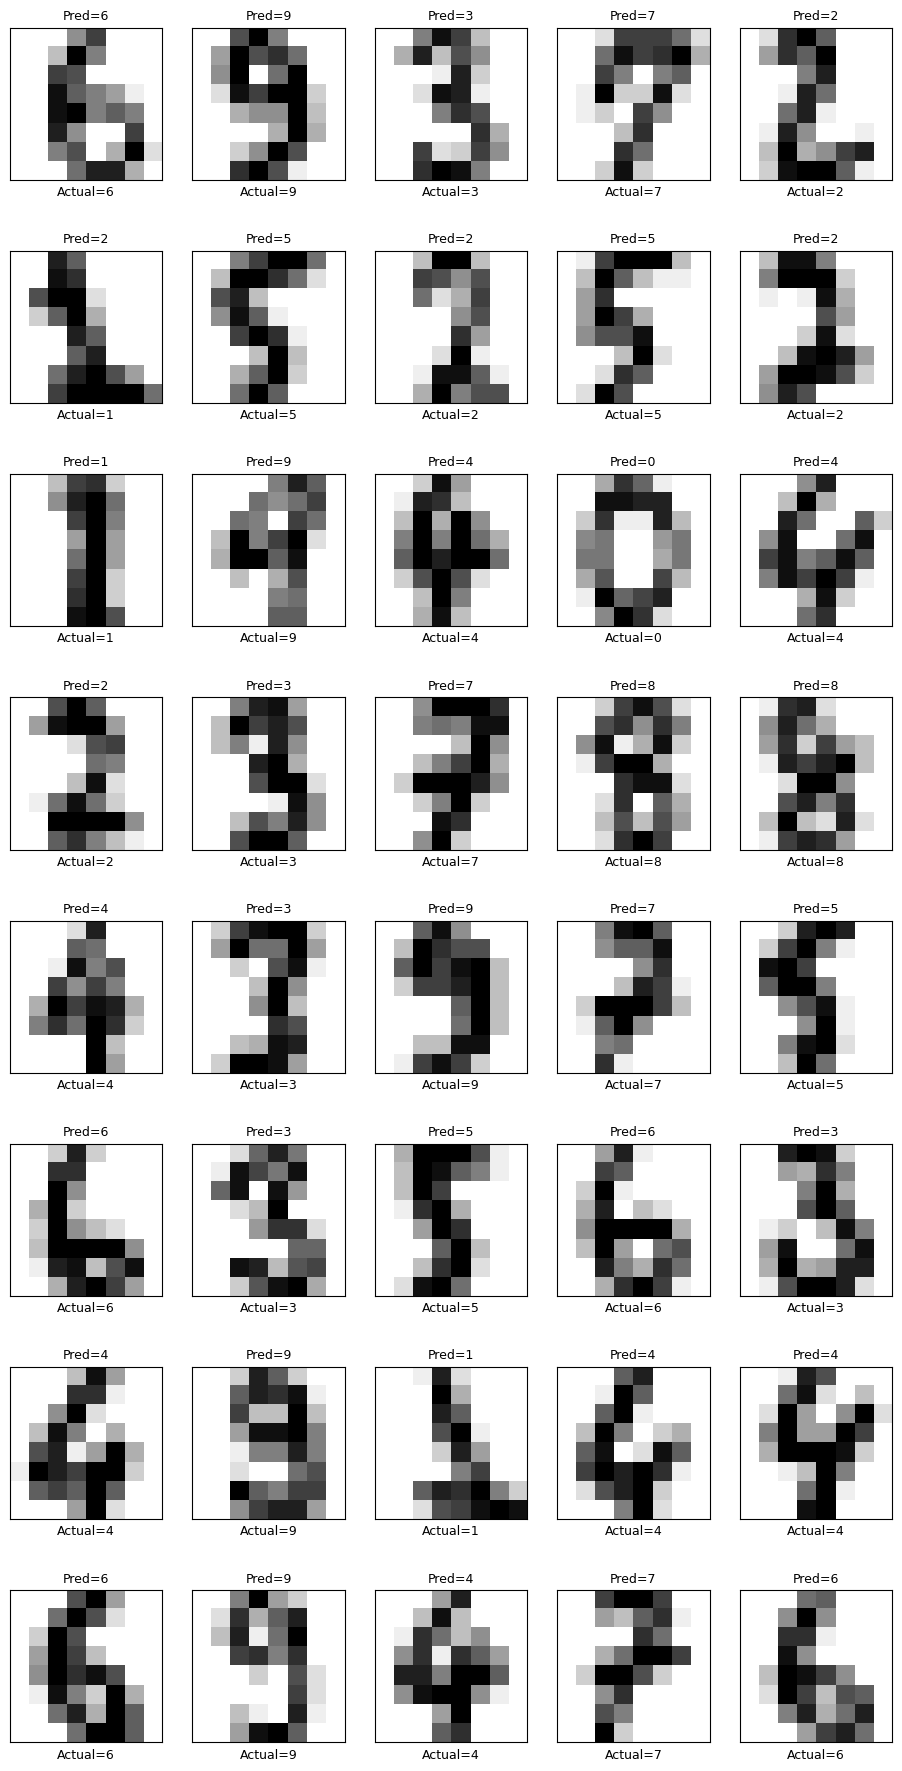

In [59]:
def plot_gallery(images, true_titles, pred_titles, categories, h, w, n_row=8, n_col=5):
    """Helper function to plot a gallery of portraits"""
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((h, w)), cmap=plt.cm.gray_r)
        plt.title('Pred='+str(categories[pred_titles[i]]), size=9)
        plt.xlabel('Actual='+str(categories[true_titles[i]]), size=9)
        plt.xticks(())
        plt.yticks(())

plot_gallery(X_test, y_test, y_pred, names, h, w)

**From this example, you may see that SVM can do multiple label classifications. It determines the decision boundaries between the 10 clusters high dimensional data points.**

---
### Generate digits

Now let's try to generate a set of standard digit images. For instance, we select all images of the label and find the cluster center of their hyper dimensional data points.  In this case, you will find the average values at each pixel in the 8x8 array.  

[0 1 2 3 4 5 6 7 8 9]


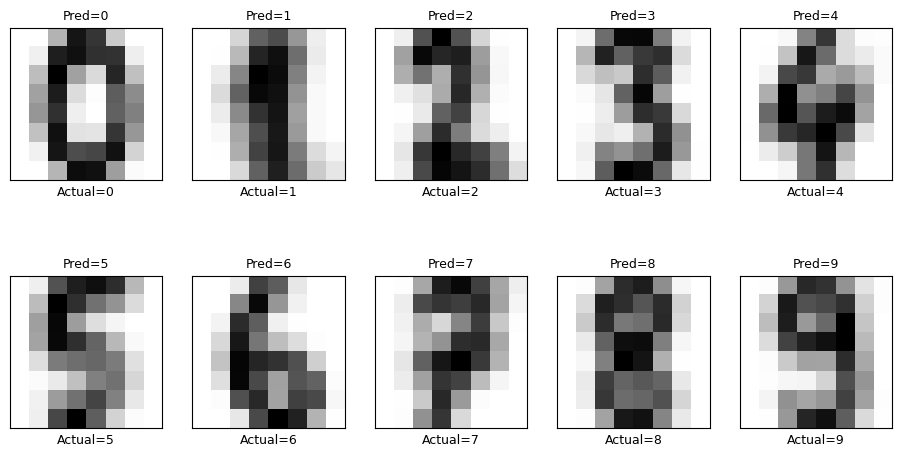

In [86]:
im_ave = np.zeros((len(names),h*w))
y_ave = np.zeros(len(names),dtype=int)

for l in range(len(names)):
    Xi = X[labels==l]
    X_ave = np.sum(Xi,axis=0)/(Xi.shape[0])
    im_ave[l,:] = X_ave
    y_ave[l,] = l
    

plot_gallery(im_ave, y_ave, y_ave, names, h, w, n_row=2, n_col=5)


&#9989; Do This - Does the average digit images make sense to you?